In [ ]:
%pip install realspace-tb

In [ ]:
import os
import sys
# 1. Get the folder where the notebook is (Folder 2)
notebook_dir = os.getcwd()

# 2. Go up one level and then into Folder 1
realspace_tb_path = os.path.abspath(os.path.join(notebook_dir, '..'))

# 3. Add to sys.path so you can import
if realspace_tb_path not in sys.path:
    sys.path.append(realspace_tb_path)

import realspace_tb as tb
import realspace_tb.orbitronics_2d as orb
import numpy as np
import matplotlib

if not hasattr(matplotlib.RcParams, '_get'):
    matplotlib.RcParams._get = lambda self, key: self.get(key)

import matplotlib.pyplot as plt
from pathlib import Path
import pickle

datapath = Path(r"/ccmtstorage/ara03989/Paper_to_publish/Paper2_a_vorticity_framework_for_origin-independent_orbital_transport/Data")
figurepath = Path(r"/ccmtstorage/ara03989/Paper_to_publish/Paper2_a_vorticity_framework_for_origin-independent_orbital_transport/Figures")

c:\Users\arist\anaconda3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def build_masked_vort_flux_observable(
    vort_flux_obs,
    plaquette_idx: int,
 ):
    keep = np.zeros_like(vort_flux_obs.values[0], dtype=bool)
    keep[plaquette_idx, :] = True   # i -> j
    keep[:, plaquette_idx] = True   # j -> i
    
    masked_values = vort_flux_obs.values.copy()
    masked_values[:, ~keep] = 0.0 # drop all flow values except those to/from the chosen plaquette

    # Build a fresh observable instance and copy masked data into it.
    new_obs = vort_flux_obs.__class__(
        vort_flux_obs._hamiltonian.geometry,
        window=vort_flux_obs.window,
        hamiltonian=vort_flux_obs._hamiltonian
    )

    new_obs.values = masked_values
    new_obs.measurement_times = vort_flux_obs.measurement_times.copy()
    
    return new_obs

# Armchair ribbon

In [3]:
Lx,Ly = 17, 10
scale = 0.0992
#scale = 1.0
t_hop = -scale
field_amplitude=orb.RampedACFieldAmplitude(E0=5e-3, omega=2*scale, T_ramp=40/scale, direction=np.array([0, 1]))
geo_ac = orb.HoneycombLatticeGeometry(
   Lx=Lx, 
   Ly=Ly, 
   pbc_x=False, 
   pbc_y=True,
)


H_ac = orb.LinearFieldHamiltonianPeierls(geo_ac, t_hop, field_amplitude)

In [12]:
field_amplitude2 = orb.RampedConstantFieldAmplitude(E0=5e-3, T_ramp=40/scale, direction=np.array([0, 1]))
H_const = orb.LinearFieldHamiltonianPeierls(geo_ac, t_hop, field_amplitude2)

In [ ]:
beta = float("inf")
rho = H_ac.thermal_state_density_matrix(fermi_level=0.0, beta=float("inf"))
vort = orb.observables.VorticityObservable(H_ac.geometry, window=tb.MeasurementWindow(stride=5, start_time=field_amplitude.T_ramp), hamiltonian=H_ac)
vort_flux = orb.observables.VortFluxObservable(H_ac.geometry, window=tb.MeasurementWindow(stride=5, start_time=field_amplitude.T_ramp), hamiltonian=H_ac)
#vort_fluxmod = orb.observables.VortFluxModObservable(H_ac.geometry, window=tb.MeasurementWindow(stride=15, start_time=field_amplitude.T_ramp), hamiltonian=H_ac)
vort_source = orb.observables.VortSourceObservable(H_ac.geometry, window=tb.MeasurementWindow(stride=5, start_time=field_amplitude.T_ramp), hamiltonian=H_ac)
vort_pol = orb.observables.VortPolObservable(H_ac.geometry, window=tb.MeasurementWindow(stride=5, start_time=field_amplitude.T_ramp), hamiltonian=H_ac)
animation = orb.observables.LatticeFrameObservable(H_ac.geometry, window=tb.MeasurementWindow(stride=5, start_time=field_amplitude.T_ramp), hamiltonian=H_ac)
vectorvort_flux = orb.observables.VectorVortFluxObservable(H_ac.geometry, window=tb.MeasurementWindow(stride=5, start_time=field_amplitude.T_ramp), hamiltonian=H_ac)
vortsrc_pol = orb.observables.VortSourcePolObservable(H_ac.geometry, window=tb.MeasurementWindow(stride=5, start_time=field_amplitude.T_ramp), hamiltonian=H_ac)
tb.RK4NeumannSolver().evolve(rho, H_ac, dt=0.005/scale, total_time=field_amplitude.T_ramp + 40/scale, observables=[animation, vort, vort_flux, vort_source,vort_pol, vectorvort_flux, vortsrc_pol], tau=float("inf"))

Calculating eigenstates at t=0...


100%|██████████| 16000/16000 [04:29<00:00, 59.46it/s]


In [50]:
rho2 = H_const.thermal_state_density_matrix(fermi_level=0.0, beta=float("inf"))
vort_pol2 = orb.observables.VortPolObservable(H_const.geometry, window=tb.MeasurementWindow(stride=15, start_time=field_amplitude2.T_ramp), hamiltonian=H_const)
animation2 = orb.observables.LatticeFrameObservable(H_const.geometry, window=tb.MeasurementWindow(stride=15, start_time=field_amplitude2.T_ramp), hamiltonian=H_const)
vectorvort_flux2 = orb.observables.VectorVortFluxObservable(H_const.geometry, window=tb.MeasurementWindow(stride=15, start_time=field_amplitude2.T_ramp), hamiltonian=H_const)
vortsrc_pol2 = orb.observables.VortSourcePolObservable(H_const.geometry, window=tb.MeasurementWindow(stride=15, start_time=field_amplitude2.T_ramp), hamiltonian=H_const)
tb.RK4NeumannSolver().evolve(rho2, H_const, dt=0.05/scale, total_time=6*(field_amplitude2.T_ramp + 40/scale), observables=[animation2, vort_pol2, vectorvort_flux2, vortsrc_pol2], tau=float("inf"))

  0%|          | 0/9600 [00:00<?, ?it/s]

100%|██████████| 9600/9600 [01:24<00:00, 113.05it/s]


In [47]:
dotvortpol = np.gradient(vort_pol.values[:,0], vort_pol.measurement_times, edge_order=2)
dotvortpol2 = np.gradient(vort_pol2.values[:,0], vort_pol2.measurement_times, edge_order=2)

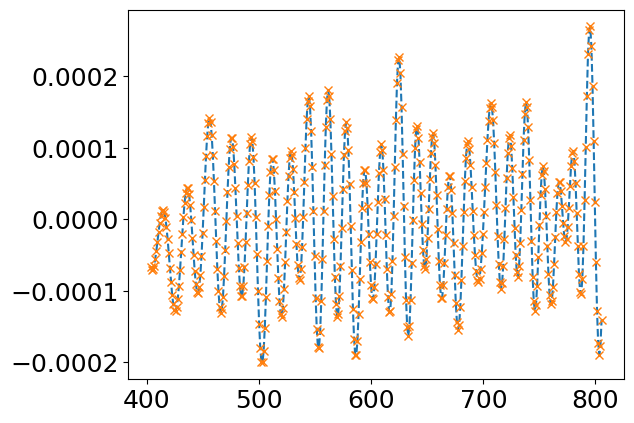

In [48]:
plt.plot(vort_pol.measurement_times[::4], dotvortpol2[::4], linestyle='--')
plt.plot(vort_pol2.measurement_times[::4], vectorvort_flux2.values[::4,0]+vortsrc_pol2.values[::4,0], linestyle='None', marker='x')

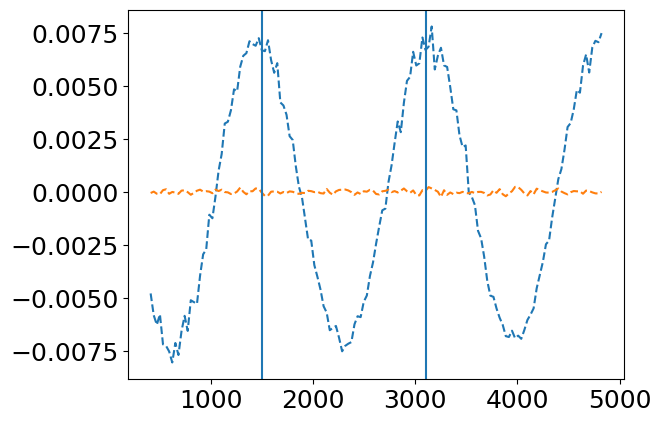

In [56]:
#plt.plot(vort_pol.measurement_times, vort_pol.values[:,0])
#plt.plot(vort_pol.measurement_times[::4], vort_pol.values[::4,0], linestyle='--')
plt.plot(vort_pol2.measurement_times[::4], vort_pol2.values[::4,0], linestyle='--')
#plt.plot(vort_pol2.measurement_times[::4], dotvortpol2[::4], linestyle='--')
#plt.plot(vort_pol.measurement_times[::4], vectorvort_flux.values[::4,0]+vortsrc_pol.values[::4,0], linestyle='--')
plt.plot(vort_pol2.measurement_times[::4], vectorvort_flux2.values[::4,0]+vortsrc_pol2.values[::4,0], linestyle='--')
plt.axvline(1500)
plt.axvline(3100)

In [8]:
measurement_times = []
efields = []
Afields = []
for m, time in enumerate(vort_pol.measurement_times):
    measurement_times.append(time)
    efields.append(field_amplitude.at_time(time))
    Afields.append(field_amplitude.integrate_to_time(time))
measurement_times = np.array(measurement_times)
efields = np.array(efields)
Afields = np.array(Afields)

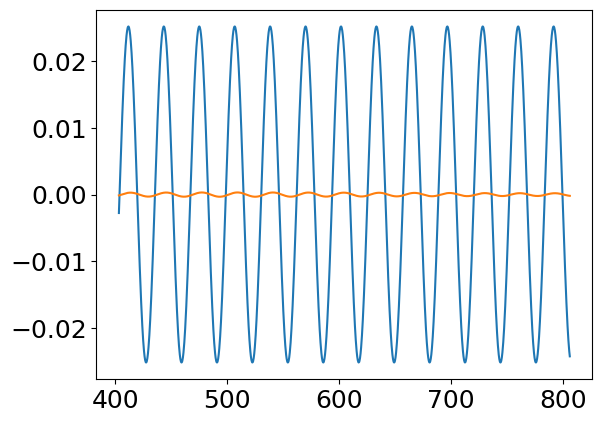

In [9]:
#plt.plot(measurement_times, efields)
plt.plot(measurement_times, -Afields)
plt.plot(measurement_times, vectorvort_flux.values[:,0])

In [ ]:
header = ['Time', 'Vortex polarization', 'Non-conserved vortex flow', 'Conserved vortex flow', 'Electric field', 'Vector potential']
length_carbon = 2.683412166
# zip(times, y1, y2) creates: (0, 10.1, 0.05), (1, 10.2, 0.06), etc.
rows = zip(measurement_times,
           vort_pol.values[:,0]/length_carbon,
           vectorvort_flux.values[:,0]/length_carbon,
           (vectorvort_flux.values[:,0]+vortsrc_pol.values[:,0])/length_carbon,
           efields,
           Afields)

with open(datapath / 'vortex_polarization_vs_time.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(rows)

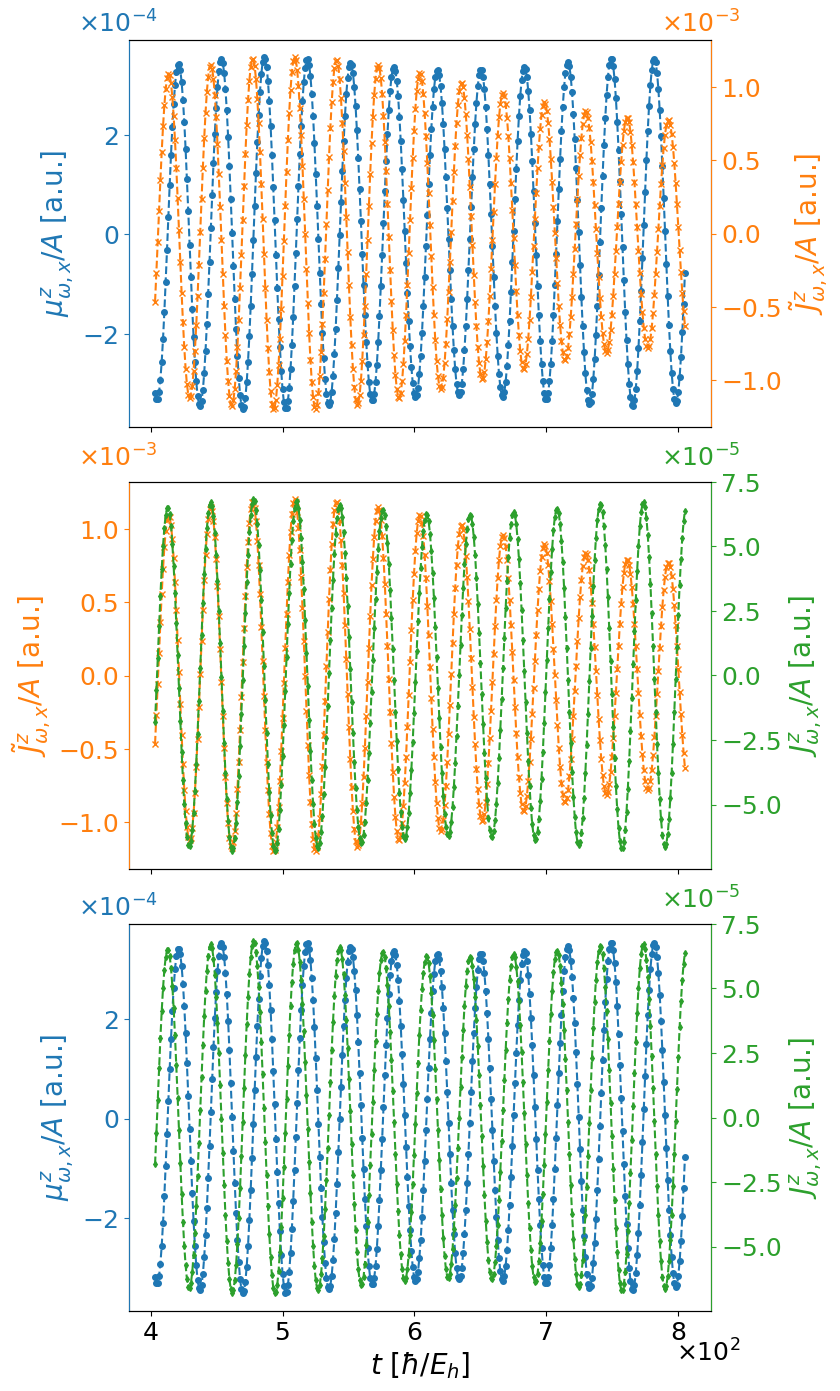

In [11]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.titlesize': 24,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
})
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8.5, 14), sharex=True)
scale_y = 10**(4)
scale_y2 = 10**(5)
scale_times = 100
fontsize = 18
length_carbon = 2.683412166
# 1. Plot the first two datasets on the LEFT y-axis
#line1, = ax1.plot(measurement_times[::4]/scale_times, vort_pol.values[::4,0]*scale_y/length_carbon, marker='o', label=r"Vortex polarization $\mu^{z}_{\omega,x}/A$", linestyle='None', markersize=4)
#line2, = ax1.plot(measurement_times[::4]/scale_times, vectorvort_flux.values[::4,0]*scale_y/length_carbon, marker='x', label=r"Vortex flow $J^{z}_{\omega,x}/A$", linestyle='None', markersize=4)
ax1.plot(measurement_times[::4]/scale_times, vort_pol.values[::4,0]*scale_y/length_carbon, marker='o', label=r"Vortex polarization $\mu^{z}_{\omega,x}/A$", linestyle='--', markersize=4,color='tab:blue')
#ax1.plot(measurement_times[::4]/scale_times, vectorvort_flux.values[::4,0]*scale_y/length_carbon, marker='x', label=r"Vortex flow $J^{z}_{\omega,x}/A$", linestyle='None', markersize=4)
ax1.spines['left'].set_color('tab:blue')
ax1.text(0.05, 1.02, r"$\times 10^{-4}$", transform=ax1.transAxes, ha='right',fontsize=fontsize,color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue', color='tab:blue')
ax1.set_ylabel(r'$\mu^{z}_{\omega,x}/A$ [a.u.]', color='tab:blue')

# 2. Create the RIGHT y-axis
ax1_twin = ax1.twinx()
#line3, = ax1_twin.plot(measurement_times/scale_times, efields*scale_yf, label=r"Electric field $\tilde{E}_{y}(t)$", linestyle='--', color='red')
ax1_twin.plot(measurement_times[::4]/scale_times, vectorvort_flux.values[::4,0]*scale_y/length_carbon, marker='x', label=r"Vortex flow $\tilde{J}^{z}_{\omega,x}/A$", linestyle='--', markersize=4, color='tab:orange')
ax1_twin.set_ylabel(r'$\tilde{J}^{z}_{\omega,x}/A$ [a.u.]', color='tab:orange')
ax1_twin.spines['left'].set_color('tab:blue')
ax1_twin.spines['right'].set_color('tab:orange')
ax1_twin.tick_params(axis='y', labelcolor='tab:orange', color='tab:orange')

ax1_twin.text(1.05, 1.02, r"$\times 10^{-3}$", transform=ax1_twin.transAxes, ha='right',fontsize=fontsize,color='tab:orange')
#lines = [line1, line2, line3]
#labels = [l.get_label() for l in lines]
#ax1_twin.legend(lines, labels, loc='upper left')

ax2_twin = ax2.twinx()
ax2.plot(measurement_times[::4]/scale_times, vectorvort_flux.values[::4,0]*scale_y/length_carbon, marker='x', label=r"Vortex flow $\tilde{J}^{z}_{\omega,x}/A$", linestyle='--', markersize=4, color='tab:orange')
ax2_twin.plot(measurement_times[::4]/scale_times, (vectorvort_flux.values[::4,0]+vortsrc_pol.values[::4,0])*scale_y2/length_carbon, marker='d', label=r"$J^{z}_{\omega},x}/A$", linestyle='--', markersize=3, color='tab:green')
ax2.set_ylabel(r'$\tilde{J}^{z}_{\omega,x}/A$ [a.u.]', color='tab:orange')
ax2_twin.set_ylabel(r'$J^{z}_{\omega,x}/A$ [a.u.]', color='tab:green')
ax2_twin.spines['left'].set_color('tab:orange')
ax2_twin.spines['right'].set_color('tab:green')
ax2_twin.tick_params(axis='y', labelcolor='tab:green', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:orange', color='tab:orange')
ax2.text(0.05, 1.04, r"$\times 10^{-3}$", transform=ax2.transAxes, ha='right', fontsize=fontsize, color='tab:orange')
ax2_twin.text(1.05, 1.04, r"$\times 10^{-5}$", transform=ax2_twin.transAxes, ha='right',fontsize=fontsize,color='tab:green')

ax3_twin = ax3.twinx()
ax3.plot(measurement_times[::4]/scale_times, vort_pol.values[::4,0]*scale_y/length_carbon, marker='o', label=r"$\mu^{z}_{\omega,x}/A$", linestyle='--', markersize=4)
ax3_twin.plot(measurement_times[::4]/scale_times, (vectorvort_flux.values[::4,0]+vortsrc_pol.values[::4,0])*scale_y2/length_carbon, marker='d', label=r"$J^{z}_{\omega,x}/A$", linestyle='--', markersize=3, color='tab:green')
ax3.tick_params(axis='y', labelcolor='tab:blue', color='tab:blue')
ax3.set_ylabel(r'$\mu^{z}_{\omega,x}/A$ [a.u.]', color='tab:blue')
ax3_twin.set_ylabel(r'$J^{z}_{\omega,x}/A$ [a.u.]', color='tab:green')
ax3_twin.tick_params(axis='y', labelcolor='tab:green', color='tab:green')
ax3_twin.text(1.05, 1.04, r"$\times 10^{-5}$", transform=ax3_twin.transAxes, ha='right',fontsize=fontsize,color='tab:green')
ax3_twin.spines['left'].set_color('tab:blue')
ax3_twin.spines['right'].set_color('tab:green')
ax3.set_xlabel(r"$t$ $[\hbar/E_{h}]$")
#ax3_twin.text(1.05, -1.35, r"$\times 10^{2}$", transform=ax1_twin.transAxes, ha='right',fontsize=fontsize)
ax3.text(0.05, 1.02, r"$\times 10^{-4}$", transform=ax3.transAxes, ha='right',fontsize=fontsize,color='tab:blue')

ax3.set_xlabel(r"$t$ $[\hbar/E_{h}]$")
ax3_twin.text(1.05, -0.13, r"$\times 10^{2}$", transform=ax3_twin.transAxes, ha='right',fontsize=fontsize)
plt.tight_layout()
plt.savefig(figurepath / 'vortex_pol2.pdf', bbox_inches='tight', dpi=600)

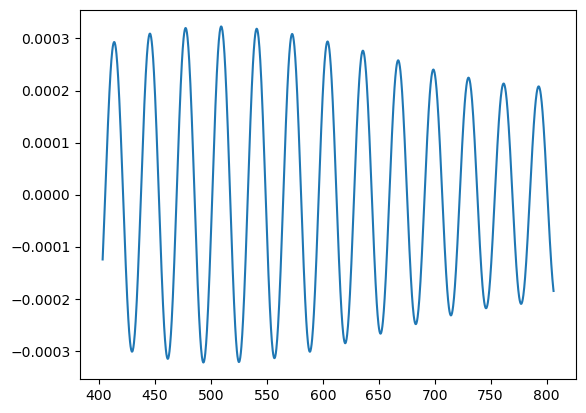

In [6]:
plt.plot(measurement_times, vectorvort_flux.values[:,0])

In [5]:
measurement_times = []
sites = [3,23,52,56]
dotvorts = []
divvortfluxs = []
vortsources = []
right_terms = []
#divvortflux_mods = []
for m, time in enumerate(vort.measurement_times):
    dotvort = []
    divvortflux = []
    #divvortflux_mod = []
    vortsource = []
    right_term = []
    if (m >= 2) and (m <= len(vort.measurement_times)-3):
        measurement_times.append(time)
        dotvort_at_m = (-vort.values[m+2]+8*vort.values[m+1]-8*vort.values[m-1]+vort.values[m-2])/(12*0.005/scale*5)
        divvortflux_at_m = np.sum(vort_flux.values[m],axis=1)
        #divvortflux_mod_at_m = np.sum(vort_fluxmod.values[m],axis=1)
        vortsource_at_m = vort_source.values[m]
        for st in sites:
            dotvort_at_m_at_st = dotvort_at_m[st]
            divvortflux_at_m_at_st = divvortflux_at_m[st]
            #divvortflux_mod_at_m_at_st = divvortflux_mod_at_m[st]
            vortsource_at_m_at_st = vortsource_at_m[st]
            dotvort.append(dotvort_at_m_at_st)
            divvortflux.append(divvortflux_at_m_at_st)
            #divvortflux_mod.append(divvortflux_mod_at_m_at_st)
            vortsource.append(vortsource_at_m_at_st)
            right_term.append(-divvortflux_at_m_at_st+vortsource_at_m_at_st)
        dotvorts.append(dotvort)
        divvortfluxs.append(divvortflux)
        #divvortflux_mods.append(divvortflux_mod)
        vortsources.append(vortsource)
        right_terms.append(right_term)
measurement_times = np.array(measurement_times)
dotvorts = np.array(dotvorts)
divvortfluxs = np.array(divvortfluxs)
#divvortflux_mods = np.array(divvortflux_mods)
vortsources = np.array(vortsources)
right_terms = np.array(right_terms)

In [ ]:
header = ['Time', 'Vortex P=3', 'Vortex P=23', 'Vortex P=52', 'Vortex P=56',
          'Divvortflux P=3', 'Divvortflux P=23', 'Divvortflux P=52', 'Divvortflux P=56',
          'Vortsource P=3', 'Vortsource P=23', 'Vortsource P=52', 'Vortsource P=56',
          'Vortsource-Divvortflux P=3', 'Vortsource-Divvortflux P=23', 'Vortsource-Divvortflux P=52', 'Vortsource-Divvortflux P=56',]
# zip(times, y1, y2) creates: (0, 10.1, 0.05), (1, 10.2, 0.06), etc.
rows = zip(measurement_times,
           dotvorts[:,0], dotvorts[:,1], dotvorts[:,2], dotvorts[:,3],
           divvortfluxs[:,0], divvortfluxs[:,1], divvortfluxs[:,2], divvortfluxs[:,3],
           vortsources[:,0], vortsources[:,1], vortsources[:,2], vortsources[:,3],
           right_terms[:,0], right_terms[:,1], right_terms[:,2], right_terms[:,3])

with open(datapath / 'cont_eq_checks.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(rows)

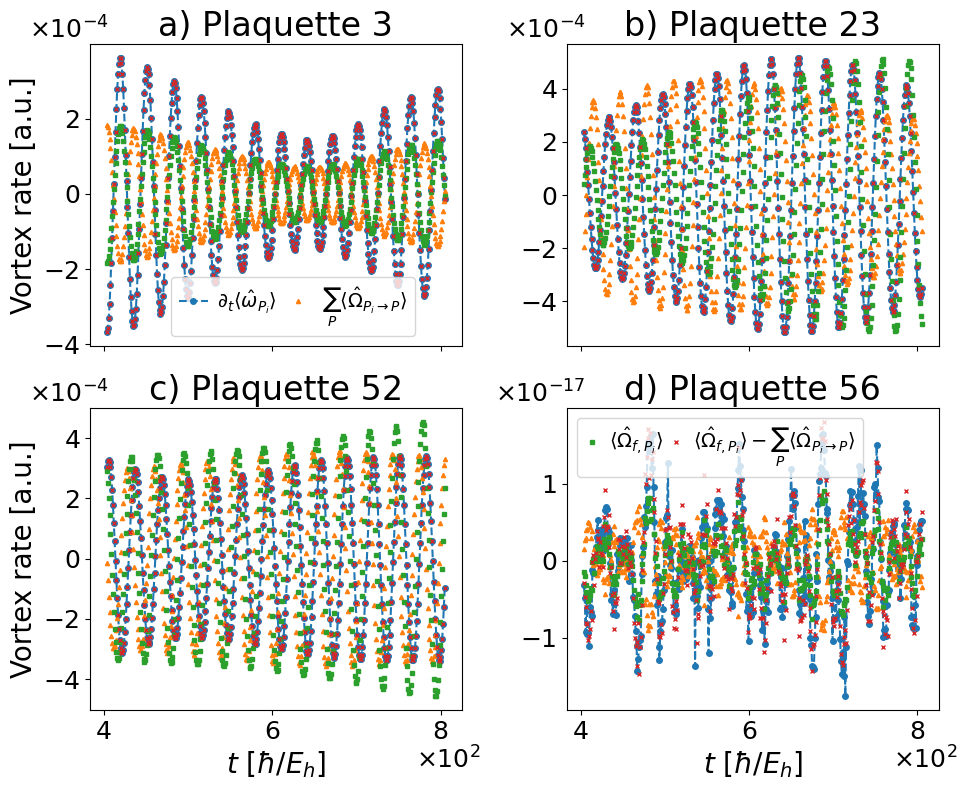

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.titlesize': 24,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 14,
})
scale_t = 0.01
scale1 = 10000.0
fig, axes = plt.subplots(2, 2, sharex=True, figsize=(10, 8))

axes[0,0].plot(measurement_times[::4]*scale_t, dotvorts[::4,0]*scale1, linestyle='--', marker='o', markersize=4, label=r'$\partial_{t}\langle\hat{\omega}_{P_{i}}\rangle$')
axes[0,0].plot(measurement_times[::4]*scale_t, divvortfluxs[::4,0]*scale1, linestyle='None', marker='^', markersize=3, label=r'$\sum_{P}\langle\hat{\Omega}_{P_{i}\rightarrow P}\rangle$')
axes[0,0].plot(measurement_times[::4]*scale_t, vortsources[::4,0]*scale1, linestyle='None',marker='s', markersize=3,label='_nolegend_')
axes[0,0].plot(measurement_times[::4]*scale_t, right_terms[::4,0]*scale1, linestyle='None',marker='x',markersize=3,label='_nolegend_')
axes[0,0].set_ylabel(r"Vortex rate [a.u.]")
axes[0,0].text(0.05, 1.02, r"$\times 10^{-4}$", transform=axes[0,0].transAxes, ha='right',fontsize=18)
axes[0,0].set_title("a) Plaquette 3")
axes[0,0].legend(loc='lower right',bbox_to_anchor=(0.9, 0.0), ncol=2,columnspacing=0.3,handletextpad=0.5,handlelength=1.5)

axes[0,1].plot(measurement_times[::4]*scale_t, dotvorts[::4,1]*scale1, linestyle='--', marker='o', markersize=4, label=r'$\partial_{t}\langle\hat{\omega}_{P_{i}}\rangle$')
axes[0,1].plot(measurement_times[::4]*scale_t, divvortfluxs[::4,1]*scale1, linestyle='None', marker='^', markersize=3, label=r'$\sum_{P}\langle\hat{\Omega}_{P_{i}\rightarrow P}\rangle$')
axes[0,1].plot(measurement_times[::4]*scale_t, vortsources[::4,1]*scale1, linestyle='None',marker='s', markersize=3,label=r'$\langle\hat{\Omega}_{f,P_{i}}\rangle$')
axes[0,1].plot(measurement_times[::4]*scale_t, right_terms[::4,1]*scale1, linestyle='None',marker='x',markersize=3,label='_nolegend_')
axes[0,1].set_title("b) Plaquette 23")
axes[0,1].text(0.05, 1.02, r"$\times 10^{-4}$", transform=axes[0,1].transAxes, ha='right',fontsize=18)

axes[1,0].plot(measurement_times[::4]*scale_t, dotvorts[::4,2]*scale1, linestyle='--', marker='o', markersize=4,label=r'$\partial_{t}\langle\hat{\omega}_{P_{i}}\rangle$')
axes[1,0].plot(measurement_times[::4]*scale_t, divvortfluxs[::4,2]*scale1, linestyle='None', marker='^', markersize=3,label=r'$\langle\hat{\Omega}_{P_{i}\rightarrow P}\rangle$')
axes[1,0].plot(measurement_times[::4]*scale_t, vortsources[::4,2]*scale1, linestyle='None',marker='s', markersize=3,label=r'$\langle\hat{\Omega}_{f,P_{i}}\rangle$')
axes[1,0].plot(measurement_times[::4]*scale_t, right_terms[::4,2]*scale1, linestyle='None',marker='x',markersize=3,label='_nolegend_')
axes[1,0].text(0.05, 1.02, r"$\times 10^{-4}$", transform=axes[1,0].transAxes, ha='right',fontsize=18)
axes[1,0].set_xlabel(r"$t$ $[\hbar/E_{h}]$")
axes[1,0].set_title("c) Plaquette 52")
axes[1,0].text(1.05, -0.12, r"$\times 10^{2}$", transform=axes[1,0].transAxes,ha='right',va='top',fontsize=18)
axes[1,0].set_ylabel(r"Vortex rate [a.u.]")

scale2 = 10**(17)
axes[1,1].plot(measurement_times[::4]*scale_t, dotvorts[::4,3]*scale2, linestyle='--', marker='o', markersize=4,label='_nolegend_')
axes[1,1].plot(measurement_times[::4]*scale_t, divvortfluxs[::4,3]*scale2, linestyle='None', marker='^', markersize=3,label='_nolegend_')
axes[1,1].plot(measurement_times[::4]*scale_t, vortsources[::4,3]*scale2, linestyle='None',marker='s', markersize=3,label=r'$\langle\hat{\Omega}_{f,P_{i}}\rangle$')
axes[1,1].plot(measurement_times[::4]*scale_t, right_terms[::4,3]*scale2, linestyle='None',marker='x',markersize=3,label=r'$\langle\hat{\Omega}_{f,P_{i}}\rangle-\sum_{P}\langle\hat{\Omega}_{P_{i}\rightarrow P}\rangle$')
axes[1,1].set_xlabel(r"$t$ $[\hbar/E_{h}]$")
axes[1,1].text(1.05, -0.12, r"$\times 10^{2}$", transform=axes[1,1].transAxes,ha='right',va='top',fontsize=18)
axes[1,1].text(0.05, 1.02, r"$\times 10^{-17}$", transform=axes[1,1].transAxes, ha='right',fontsize=18)
axes[1,1].legend(loc='upper left', ncol=2,columnspacing=0.3,handletextpad=0.5,handlelength=0.75)
axes[1,1].set_title("d) Plaquette 56")
#axes[1,1].set_ylabel(r"$\times 10^{-17}$")

plt.tight_layout()
plt.savefig(figurepath / 'cont_eq_terms.pdf', bbox_inches='tight')

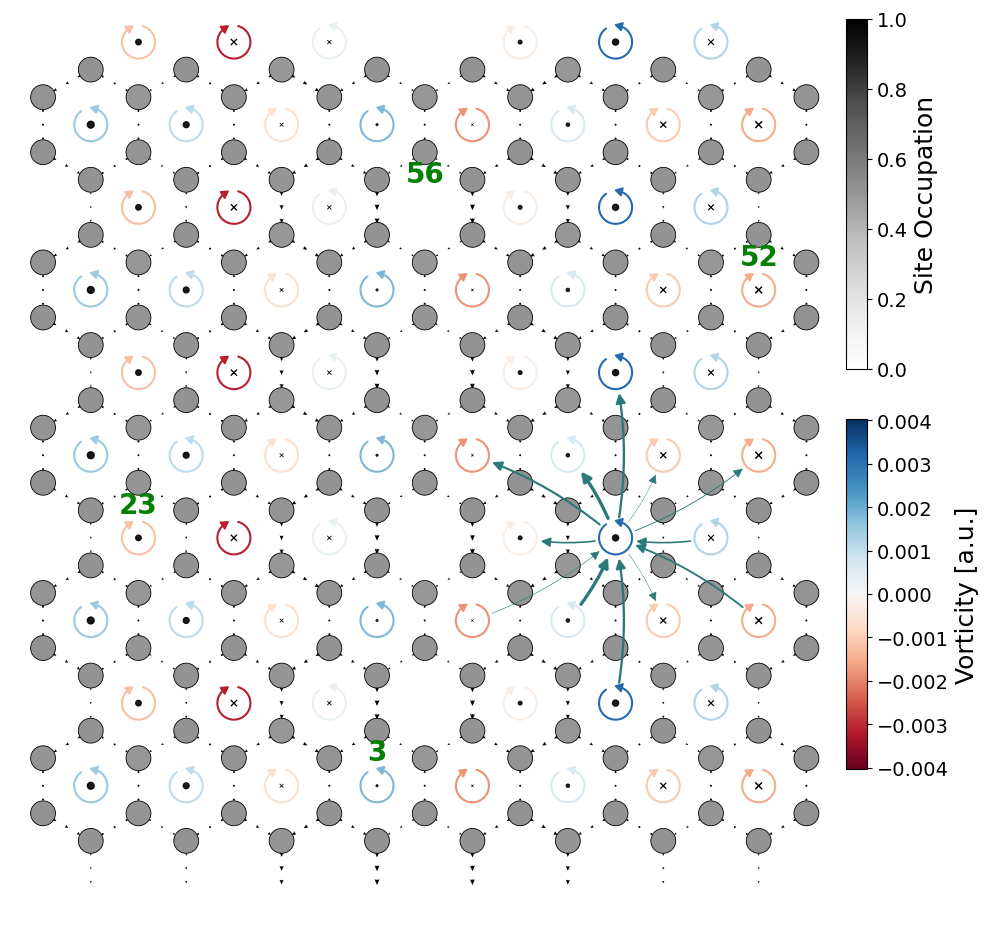

In [ ]:
from realspace_tb.orbitronics_2d.plot_utils import PlotConfig
config = orb.PlotConfig(
    show_bfield_underlay=False,
    # B_z in plane 1 a_NN above the ribbon
    bfield_z_height=1,
    # b field resoultion
    bfield_x_pixels=120,
    bfield_y_pixels=80,
    # b field extent margin beyond the lattice geometry extent
    bfield_x_margin=3,
    bfield_alpha=0.8,
    # adjust the circular arrows to have a continous colormap instead of discrete red / blue colors
    oam_arrow_color_mode="continuous",
    # show the arrows
    show_oam_indicators=True,

    # shrink the length of the vorticity flow arrows to not cut into the oam / voricity arrows
    vorticity_flow_shrink=15,

    # could scale make them bigger
    # vorticity_flow_max_linewidth=5.0,
    
    # include the legend box
    show_legend=False,
    legend_fontsize = 16.0,
    # do not show the site occupation in the legend
    legend_show_site_occupation=True,
    # do not show the site occupation colorbar
    show_density_colorbar=True,
    # do show the colorbar for the ring current / oam / vorticity arrows.
    # one could adjust it to BrBG to differ from b field
    # oam_cmap="BrBG"
    show_oam_colorbar=True,
    # scale of the vorticity source markers
    vorticity_source_marker_size=70,
    
    # slightly curve the vorticity flow arrows to make them visually distinct if they overlap with themselves
    vorticity_flow_curvature=0.1,

    # hide vorticity flow arrows with < 20% of the maximum flow
    vorticity_flow_threshold=0.2,

    # color used in legend for Vorticity
    oam_arrow_positive_color="#629ac4",

    # width and spacing of colorbars
    colorbar_width=0.015,
    # Adjust the fontsize
    colorbar_site_occupation_fontsize=18,
    colorbar_site_occupation_textsize=14,
    colorbar_oam_fontsize=18,
    colorbar_oam_textsize=14,
    # Legend labels
    legend_vorticity_flow_label="Vorticity Flow",
    legend_vorticity_source_label="Vorticity Source ($\\times$ = pos., $\\cdot$ = neg.)",
)

max_frame_idx = np.argmax(np.linalg.norm(vort_pol.values[:,0]))

i = 28  # plaquette index of interest
vort_flux_masked = build_masked_vort_flux_observable(vort_flux, i)

# set threshold to 0 to show all flow arrows in the masked observable
config.vorticity_flow_threshold = 0.0

fig, ax = orb.show_simulation_frame(
    animation,
    frame=100,#max_frame_idx-1,
    vort_source_obs=vort_source,
    vort_flow_obs=vort_flux_masked,
    config=config,
    show=False,
)


geom = animation.geometry
positions = geom.site_positions
centers = geom.plaquettes[1]
# Sort: Sweep from bottom to top (Y), then left to right (X)
# We round Y to 1 decimal place to align the zig-zagging hexagons into rows
centers_sorted = sorted(centers, key=lambda c: (round(c[1], 1), c[0]))
#print(centers)
target_indices = [3,23,52,56]
for idx in target_indices:
    if idx < len(centers_sorted):
        cx, cy = centers_sorted[idx]
        #ax.plot(cx, cy, 'x', markersize=32, color='green',zorder=10) # Red dot
        ax.text(cx, cy + 0.35, str(idx), color='green', fontsize=20, 
                fontweight='bold', ha='center', va='bottom', zorder=11)

cax1 = fig.axes[1]
pos1 = cax1.get_position()
cax2 = fig.axes[2]
pos2 = cax2.get_position()

cax1.set_position([pos1.x0-0.015, pos1.y0, pos2.width, pos2.height])
cax2.set_position([pos1.x0-0.015, pos1.y0-0.4, pos2.width, pos2.height])


#plt.savefig(r"C:\Users\arist\Documents\Studium (Dr.rer.nat)\Paper_to_publish\Paper2_a_vorticity_framework_for_origin-independent_orbital_transport\snapshot_TB.pdf", bbox_inches="tight")

C:\Users\arist\AppData\Local\Temp\ipykernel_16208\3600019510.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


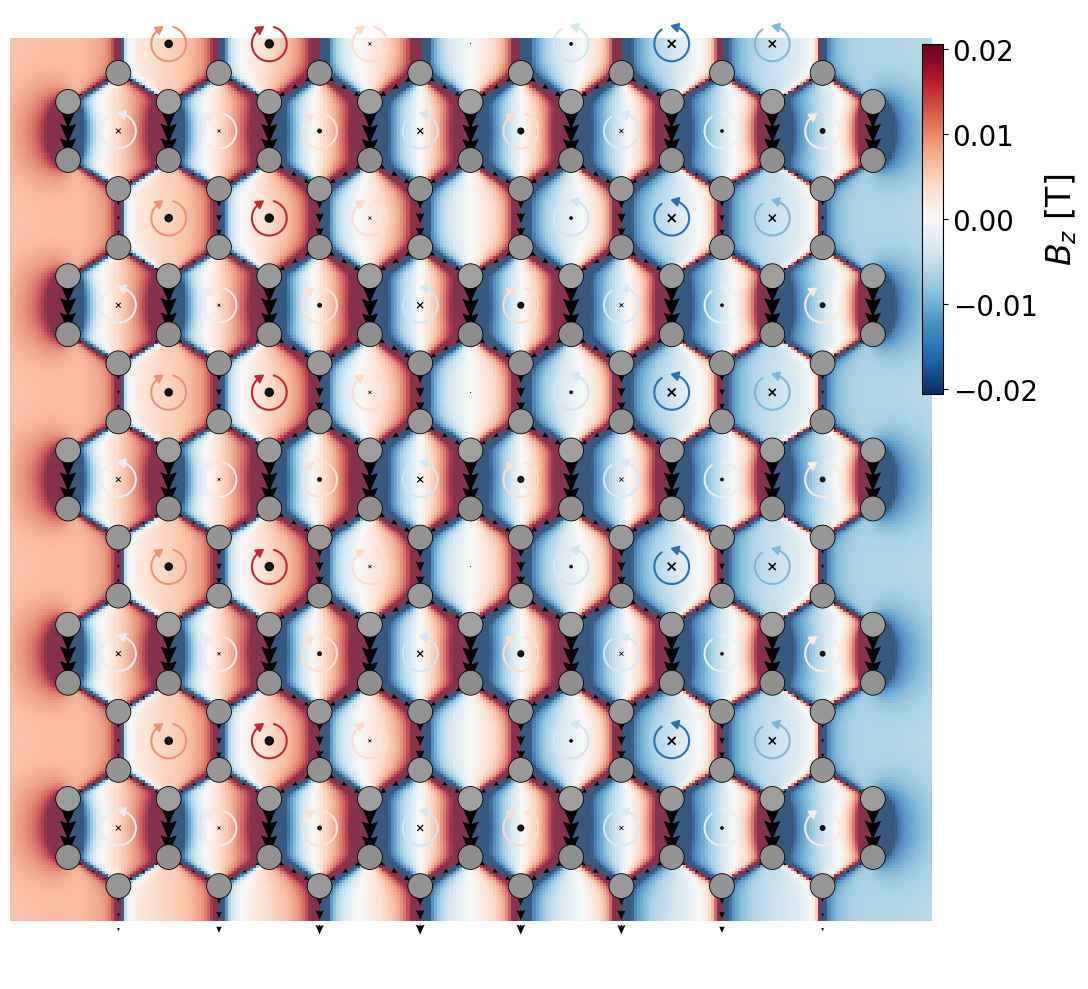

In [8]:
max_frame_idx = np.argmax(vort_pol.values[:,0])
min_frame_idx = np.argmin(np.abs(vort_pol.values[:,0]))
config = orb.PlotConfig(
    show_bfield_underlay=True,
    # B_z in plane 1 a_NN above the ribbon
    bfield_z_height=0*0.25,
    # b field resoultion
    bfield_x_pixels=300,
    bfield_y_pixels=300,
    # b field extent margin beyond the lattice geometry extent
    bfield_x_margin=1,
    bfield_alpha=0.8,
    # adjust the circular arrows to have a continous colormap instead of discrete red / blue colors
    oam_arrow_color_mode="continuous",
    # show the arrows
    show_oam_indicators=True,

    # shrink the length of the vorticity flow arrows to not cut into the oam / voricity arrows
    vorticity_flow_shrink=15,

    # could scale make them bigger
    # vorticity_flow_max_linewidth=5.0,
    
    # include the legend box
    show_legend=False,
    # do not show the site occupation in the legend
    legend_show_site_occupation=False,
    # do not show the site occupation colorbar
    show_density_colorbar=False,
    # do show the colorbar for the ring current / oam / vorticity arrows.
    # one could adjust it to BrBG to differ from b field
    # oam_cmap="BrBG"
    show_oam_colorbar=False,
    # scale of the vorticity source markers
    vorticity_source_marker_size=70,
    
    # slightly curve the vorticity flow arrows to make them visually distinct if they overlap with themselves
    vorticity_flow_curvature=0.1,

    # hide vorticity flow arrows with < 20% of the maximum flow
    vorticity_flow_threshold=0.2,

    # color used in legend for Vorticity
    oam_arrow_positive_color="#629ac4",

    # width and spacing of colorbars
    colorbar_width=0.015,
    colorbar_bfield_fontsize= 24,
    colorbar_bfield_textsize= 20,

    # Legend labels
    legend_vorticity_flow_label="Vorticity Flow",
    legend_vorticity_source_label="Vorticity Source ($\\times$ = pos., $\\cdot$ = neg.)",
)

# adjust config.bfield_vmin and vmax based on the maximum absolute value in the bz sample
_, _, bzsample = orb.biot_savart.biot_savart_on_plane(
    np.linspace(0, H_ac.geometry.extent_along([1, 0]), 50),
    np.linspace(0, H_ac.geometry.extent_along([0, 1]), 50),
    config.bfield_z_height,
    animation.values["currents"][max_frame_idx],
    H_ac.geometry,
)
# _, _, bzsample2 = orb.biot_savart.biot_savart_on_plane(
#     np.linspace(0, H_ac.geometry.extent_along([1, 0]), 50),
#     np.linspace(0, H_ac.geometry.extent_along([0, 1]), 50),
#     config.bfield_z_height,
#     animation.values["currents"][min_frame_idx],
#     H_ac.geometry,
# )

#bmax = 1.03 * np.max(np.abs(bzsample))
bmax = 1.03 * 0.02
config.bfield_vmin = -bmax
config.bfield_vmax = bmax
config.vorticity_flow_threshold = 0.4
fig, ax = orb.show_simulation_frame(
    animation,
    frame=max_frame_idx,
    vort_source_obs=vort_source,
    vort_flow_obs=None,
    config=config,
    show=False
)
# fig2, ax2 = orb.show_simulation_frame(
#     animation,
#     frame=min_frame_idx,
#     vort_source_obs=vort_source,
#     vort_flow_obs=None,
#     config=config,
#     show=False
# )
# 1. Set your crop
#ax1.set_xlim(left=5, right=5)
#ax1.set_ylim(top=-5, bottom=10) 

# 2. Crucial: Tell Matplotlib to ignore the old 'equal' constraints 
# for the purpose of the figure box, but keep the lattice shape
#ax1.set_adjustable("box") 

# 3. Use 'constrained_layout' to force the colorbar to snap to the new axis edge
#fig1.set_layout_engine('constrained')

# 4. Resize the figure window so it isn't so "tall"
# If the original height was 6 inches, let's try 4
#w, h = fig1.get_size_inches()
#fig1.set_size_inches(w, h)
plt.tight_layout()
#plt.savefig('just_for_label.pdf', bbox_inches='tight', dpi=600)

In [9]:
bzsample.shape

(50, 50, 3)

In [ ]:
cax1 = fig.axes[1]
pos1 = cax1.get_position()
cax2 = fig.axes[2]
pos2 = cax2.get_position()

cax1.set_position([pos1.x0-0.015, pos1.y0, pos2.width, pos2.height])
cax2.set_position([pos1.x0-0.015, pos1.y0-0.4, pos2.width, pos2.height])

#plt.show()
plt.savefig(r"C:\Users\arist\Documents\Studium (Dr.rer.nat)\Paper_to_publish\Paper2_a_vorticity_framework_for_origin-independent_orbital_transport\snapshot_TB.pdf", bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

In [ ]:
electric_field_vectors = [field_amplitude.at_time(t) * field_amplitude.direction for t in animation.measurement_times]
orb.save_simulation_animation(animation, "zz.mp4", 
                              electric_field_vectors=electric_field_vectors,
                              field_arrow_label="$\\vec E(t)$",
                              field_arrow_color="#14B8A6",
                              )

In [ ]:
# not for 29, but 27 and 31

# for 12, 11
# not for strong damping
# Ly dependent?!
# only for 1.98 < omega and annoying horizintal modes appear at 2.5. So

In [ ]:
# plot the currents: this shows how the currents are stronger in the center
max_orb_pol = np.argmax(orb_pol.values[:, 0])
plt.plot(np.abs(animation.values["currents"][max_orb_pol-1]))
print(f"Maximum orbital polarization at time {orb_pol.measurement_times[max_orb_pol]:.2f} with value {orb_pol.values[max_orb_pol, 0]:.4f}")

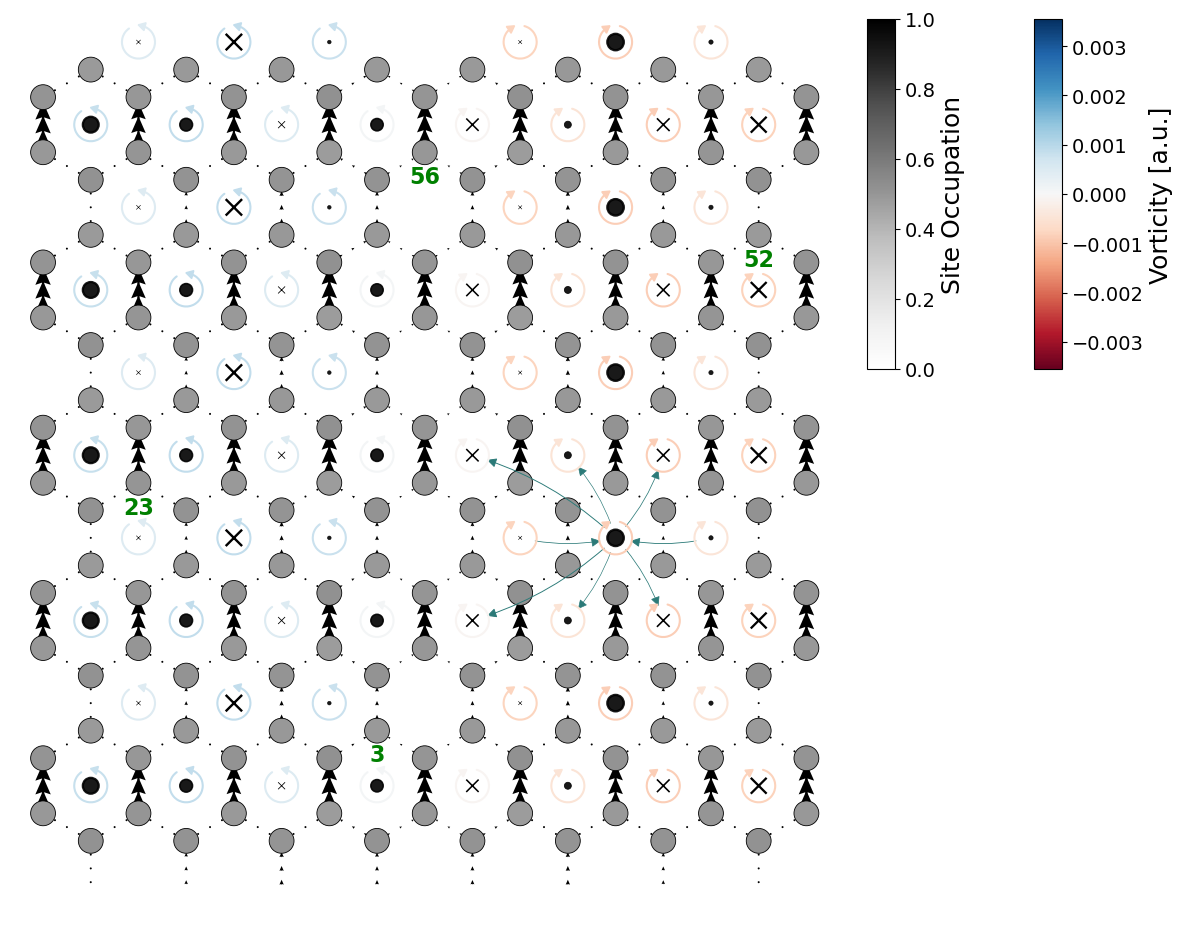

In [24]:
from realspace_tb.orbitronics_2d.plot_utils import PlotConfig
config = PlotConfig(
    show_flow_arrows=True,           # Removes bond currents
    show_oam_indicators=True,        # Removes curl/vorticity scatter
    show_oam_direction_arrows=True,  # Removes curved arrows
    oam_arrow_color_mode="continuous",
    show_oam_colorbar=True,
    colorbar_site_occupation_fontsize=18,
    colorbar_site_occupation_textsize=14,
    colorbar_oam_fontsize=18,
    colorbar_oam_textsize=14,
    frame_texts=[""] * len(animation.measurement_times)
)

fig, ax = orb.show_simulation_frame(
    animation,
    frame=max_frame_idx,
    config=config,
    vort_flow_obs=vort_flux_masked,
    vort_source_obs=vort_source,
    #frame_texts=[""]* len(animation.measurement_times),
    show=False, # to use savefig
)

geom = animation.geometry
positions = geom.site_positions
centers = geom.plaquettes[1]
# Sort: Sweep from bottom to top (Y), then left to right (X)
# We round Y to 1 decimal place to align the zig-zagging hexagons into rows
centers_sorted = sorted(centers, key=lambda c: (round(c[1], 1), c[0]))
#print(centers)
target_indices = [3,23,52,56]
for idx in target_indices:
    if idx < len(centers_sorted):
        cx, cy = centers_sorted[idx]
        #ax.plot(cx, cy, 'x', markersize=32, color='green',zorder=10) # Red dot
        ax.text(cx, cy + 0.35, str(idx), color='green', fontsize=16, 
                fontweight='bold', ha='center', va='bottom', zorder=11)
#plt.show()
plt.savefig(r"C:\Users\arist\Documents\Studium (Dr.rer.nat)\Paper_to_publish\Paper2_a_vorticity_framework_for_origin-independent_orbital_transport\snapshot_TB.pdf", bbox_inches="tight")

# Zigzag Nanoribbon

In [ ]:
field_amplitude=orb.RampedACFieldAmplitude(E0=1e-3, omega=0.5, T_ramp=40, direction=np.array([1, 0]))
geo_zz = orb.HoneycombLatticeGeometry(
    Lx=10, 
    Ly=13, 
    pbc_x=True, 
    pbc_y=False,
)

H_zz = orb.LinearFieldHamiltonianPeierls(geo_zz, field_amplitude)
rho = H_zz.ground_state_density_matrix(fermi_level=0.0)
animation = orb.observables.LatticeFrameObservable(H_zz.geometry, window=tb.MeasurementWindow(stride=15, start_time=field_amplitude.T_ramp), hamiltonian=H_zz)
orb_pol = orb.observables.OrbitalPolarizationObservable(H_zz.geometry, window=tb.MeasurementWindow(stride=15, start_time=field_amplitude.T_ramp), hamiltonian=H_zz)
tb.RK45Solver().evolve(rho, H_zz, dt=0.01, total_time=field_amplitude.T_ramp + 50, observables=[animation, orb_pol], tau=20)

In [ ]:
max_orb_pol = np.argmax(orb_pol.values[:, 1])
print(f"Maximum orbital polarization at time {orb_pol.measurement_times[max_orb_pol]:.2f} with value {orb_pol.values[max_orb_pol, 1]:.4f}")

orb.show_simulation_frame(
    animation,
    max_orb_pol+15,
    show_oam_direction_arrows=True,
    frame_texts=[""]* len(animation.measurement_times),
    oam_arrow_threshold=0.0001,
    show=False, # to use savefig
)

plt.savefig("zz_max_orb_pol.pdf", bbox_inches="tight")

In [ ]:
electric_field_vectors = [field_amplitude.at_time(t) * field_amplitude.direction for t in animation.measurement_times]
orb.save_simulation_animation(animation, "zz.mp4", 
                              electric_field_vectors=electric_field_vectors,
                              field_arrow_label="$\\vec E(t)$",
                              field_arrow_color="#14B8A6",
                              field_arrow_type="horizontal",
                              )

In [ ]:
def save_findings(animation, zz_ribbon, dirname):
    # make a directory at dirname
    findings_dir = Path(dirname)
    findings_dir.mkdir(exist_ok=False)

    pickle_path = findings_dir / "geometry.pickle"
    with pickle_path.open("b+w") as f:
        pickle.dump(zz_ribbon, f)

    markdown_path = findings_dir / "stats.md"
    with markdown_path.open("w") as md:
        md.writelines([f"---\n{key}: {value}\n\n" for key, value in zz_ribbon.field_amplitude.__dict__.items()])
        md.writelines([f"---\n{key}: {value}\n\n" for key, value in zz_ribbon.__dict__.items()])
        
    anim_path = findings_dir / "animation.mp4"
    orb.save_simulation_animation(animation, anim_path)

In [ ]:
save_findings(animation, H_ac, "niceSeparationVanHove3")